In [1]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

# ---------------------------
# Configuration
# ---------------------------
DATA_ROOT = "BTMK"        # <-- put your dataset path here
IMG_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 20
LR = 1e-3
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# ---------------------------
# Data Transforms
# ---------------------------
train_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(20),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406], [0.229,0.224,0.225])
])

val_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406], [0.229,0.224,0.225])
])

# ---------------------------
# Datasets & Loaders
# ---------------------------
train_ds = datasets.ImageFolder(os.path.join(DATA_ROOT, "train"), train_tf)
val_ds   = datasets.ImageFolder(os.path.join(DATA_ROOT, "val"), val_tf)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)

NUM_CLASSES = len(train_ds.classes)
print("Classes:", train_ds.classes)

# ---------------------------
# SIMPLE CNN MODEL
# ---------------------------
class SimpleCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * (IMG_SIZE//8) * (IMG_SIZE//8), 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

model = SimpleCNN(NUM_CLASSES).to(DEVICE)

# ---------------------------
# Loss & Optimizer
# ---------------------------
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LR)

# ---------------------------
# Training Function
# ---------------------------
def train_one_epoch():
    model.train()
    total, correct, loss_sum = 0, 0, 0
    for x, y in train_loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        optimizer.zero_grad()
        outputs = model(x)
        loss = criterion(outputs, y)
        loss.backward()
        optimizer.step()

        loss_sum += loss.item() * x.size(0)
        correct += (outputs.argmax(1) == y).sum().item()
        total += y.size(0)

    return loss_sum/total, correct/total

# ---------------------------
# Validation Function
# ---------------------------
def evaluate():
    model.eval()
    total, correct, loss_sum = 0, 0, 0
    preds, labels = [], []

    with torch.no_grad():
        for x, y in val_loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            outputs = model(x)
            loss = criterion(outputs, y)

            loss_sum += loss.item() * x.size(0)
            correct += (outputs.argmax(1) == y).sum().item()
            total += y.size(0)

            preds.extend(outputs.argmax(1).cpu().numpy())
            labels.extend(y.cpu().numpy())

    return loss_sum/total, correct/total, preds, labels

# ---------------------------
# TRAIN LOOP
# ---------------------------
best_acc = 0
for epoch in range(1, EPOCHS+1):
    train_loss, train_acc = train_one_epoch()
    val_loss, val_acc, preds, labels = evaluate()

    print(f"Epoch {epoch:02d}: "
          f"Train Acc {train_acc:.4f} | Val Acc {val_acc:.4f}")

    # Save best model
    if val_acc > best_acc:
        best_acc = val_acc
        torch.save(model.state_dict(), "best_cnn.pth")
        print("Saved best model.")

print("\nTraining Completed.")
print("Best Val Accuracy:", best_acc)

# ---------------------------
# Final Evaluation Report
# ---------------------------
print("\nClassification Report:")
print(classification_report(labels, preds, target_names=train_ds.classes))

print("\nConfusion Matrix:")
print(confusion_matrix(labels, preds))


Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']
Epoch 01: Train Acc 0.6868 | Val Acc 0.8127
Saved best model.
Epoch 02: Train Acc 0.8256 | Val Acc 0.8546
Saved best model.
Epoch 03: Train Acc 0.8590 | Val Acc 0.8707
Saved best model.
Epoch 04: Train Acc 0.8744 | Val Acc 0.8916
Saved best model.
Epoch 05: Train Acc 0.9029 | Val Acc 0.8992
Saved best model.
Epoch 06: Train Acc 0.9180 | Val Acc 0.9287
Saved best model.
Epoch 07: Train Acc 0.9330 | Val Acc 0.9344
Saved best model.
Epoch 08: Train Acc 0.9414 | Val Acc 0.9420
Saved best model.
Epoch 09: Train Acc 0.9540 | Val Acc 0.9477
Saved best model.
Epoch 10: Train Acc 0.9544 | Val Acc 0.9458
Epoch 11: Train Acc 0.9611 | Val Acc 0.9458
Epoch 12: Train Acc 0.9609 | Val Acc 0.9553
Saved best model.
Epoch 13: Train Acc 0.9672 | Val Acc 0.9610
Saved best model.
Epoch 14: Train Acc 0.9735 | Val Acc 0.9648
Saved best model.
Epoch 15: Train Acc 0.9711 | Val Acc 0.9601
Epoch 16: Train Acc 0.9719 | Val Acc 0.9610
Epoch 17: Train Acc 0.

Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']
Test Samples: 1057
Loaded model: best_cnn.pth

===== TEST RESULTS =====
Accuracy: 0.9603
F1 Score: 0.9602

Classification Report:
              precision    recall  f1-score   support

      glioma       0.93      0.96      0.95       244
  meningioma       0.94      0.91      0.92       248
     notumor       0.99      0.98      0.98       300
   pituitary       0.98      0.99      0.98       265

    accuracy                           0.96      1057
   macro avg       0.96      0.96      0.96      1057
weighted avg       0.96      0.96      0.96      1057



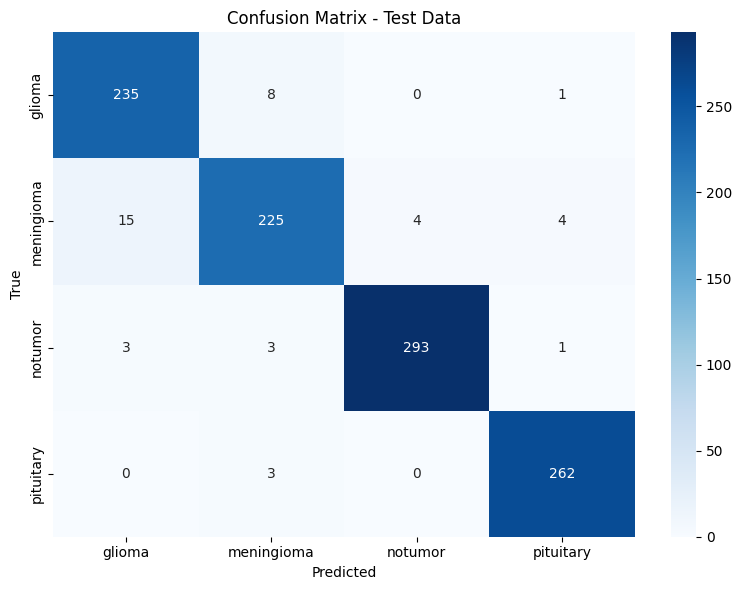

In [2]:
import os
import torch
import torch.nn as nn
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# -----------------------------
# CONFIG
# -----------------------------
TEST_DIR = "BTMK/test"     # <-- Change this
MODEL_PATH = "best_cnn.pth"   # <-- Your saved model
IMG_SIZE = 224
BATCH_SIZE = 32
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# -----------------------------
# DATA TRANSFORMS
# -----------------------------
test_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

# -----------------------------
# LOAD DATA
# -----------------------------
test_ds = datasets.ImageFolder(TEST_DIR, transform=test_tf)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

class_names = test_ds.classes
NUM_CLASSES = len(class_names)
print("Classes:", class_names)
print("Test Samples:", len(test_ds))

# -----------------------------
# LOAD MODEL
# -----------------------------
# Must match the architecture of the model you trained
class SimpleCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * (IMG_SIZE//8) * (IMG_SIZE//8), 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

# Load model
model = SimpleCNN(NUM_CLASSES).to(DEVICE)
model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
model.eval()

print("Loaded model:", MODEL_PATH)

# -----------------------------
# RUN TEST INFERENCE
# -----------------------------
all_preds = []
all_labels = []

with torch.no_grad():
    for imgs, labels in test_loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)

        outputs = model(imgs)
        preds = outputs.argmax(1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# -----------------------------
# METRICS
# -----------------------------
acc = accuracy_score(all_labels, all_preds)
f1 = f1_score(all_labels, all_preds, average="weighted")

print("\n===== TEST RESULTS =====")
print(f"Accuracy: {acc:.4f}")
print(f"F1 Score: {f1:.4f}\n")

print("Classification Report:")
print(classification_report(all_labels, all_preds, target_names=class_names))

# -----------------------------
# CONFUSION MATRIX (SEABORN)
# -----------------------------
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names,
            yticklabels=class_names)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix - Test Data")
plt.tight_layout()
plt.show()
